## 1.Importing liberaries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

## 2. Loading Dataset

In [2]:
# df = pd.read_csv("netflix_titles.csv")
df = pd.read_csv("../dataset/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Dataset Overview

In [3]:
# number of rows and columns
df.shape

(8807, 12)

In [4]:
# columns names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
# data types of each column
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [6]:
# gives us the number of non-null values in each column, which is useful for identifying missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe()
# statistical summary of the DataFrame, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values for each numerical column.
#  This helps us understand the distribution and central tendency of the data.

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### Explanation from analysis:
#### The dataset contains information about Netflix titles including type, director, cast, country, release year, rating, and duration.

## 4.Data Cleaning

In [8]:
# Checking for missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
# assesing the data
df.isnull().sum()/ len(df)*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [10]:
# cloumns director, cast and country have missing values. Here, we will fill them with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

C:\Users\premier\AppData\Local\Temp\ipykernel_4656\334052619.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\premier\AppData\Local\Temp\ipykernel_4656\334052619.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [11]:
# Droping rows with very small missing values
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)
# boht chooti value mising thi to row hi delete kr di

In [12]:
df.shape
# print (8807-8790)  # = 17 rows droped

(8790, 12)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
# again checking for missing values
df.isnull().sum()/ len(df)*100

show_id         0.0
type            0.0
title           0.0
director        0.0
cast            0.0
country         0.0
date_added      0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
description     0.0
dtype: float64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


## 5. Exploratory Data Analysis

In [16]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [18]:
df['duration'].value_counts()

duration
1 Season     1791
2 Seasons     421
3 Seasons     198
90 min        152
97 min        146
             ... 
228 min         1
18 min          1
205 min         1
201 min         1
191 min         1
Name: count, Length: 220, dtype: int64

In [19]:
df.nunique()

show_id         8790
type               2
title           8790
director        4527
cast            7679
country          749
date_added      1765
release_year      74
rating            14
duration         220
listed_in        513
description     8758
dtype: int64

<Axes: xlabel='type'>

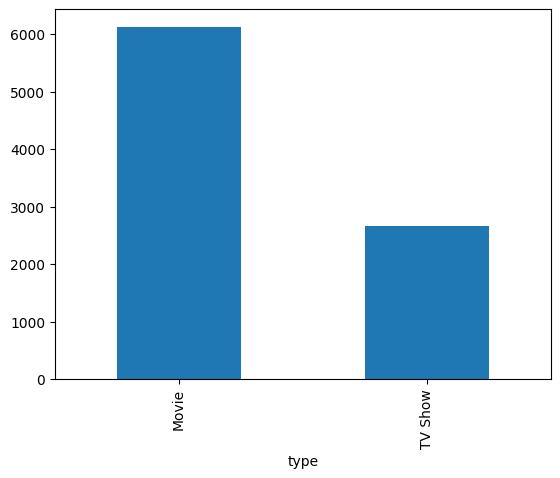

In [20]:
df["type"].value_counts().plot(kind="bar")

Text(0.5, 1.0, 'Distribution of Movies and TV Shows')

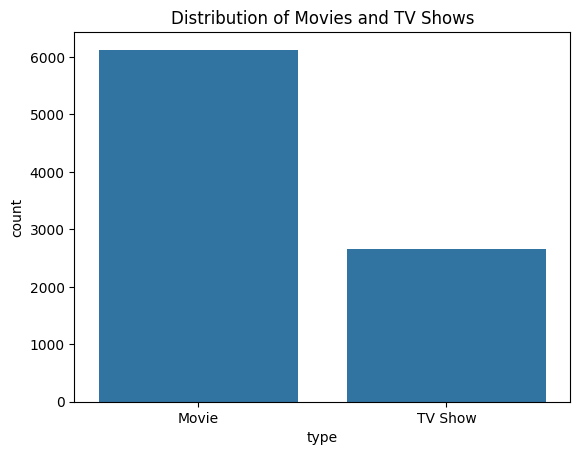

In [21]:
sns.countplot(x="type", data=df)
plt.title("Distribution of Movies and TV Shows")

 ### Taking the count of ratings available

In [22]:
x = df.groupby(['rating']).size().reset_index(name='counts')
print(x)
# grouping the data by 'rating' and counting the occurrences of each rating, then resetting the index to create a new DataFrame with columns 'rating' and 'counts'. Finally, it prints the resulting DataFrame.

      rating  counts
0          G      41
1      NC-17       3
2         NR      79
3         PG     287
4      PG-13     490
5          R     799
6      TV-14    2157
7       TV-G     220
8      TV-MA    3205
9      TV-PG     861
10      TV-Y     306
11     TV-Y7     333
12  TV-Y7-FV       6
13        UR       3


### Creating the piechart based on content rating

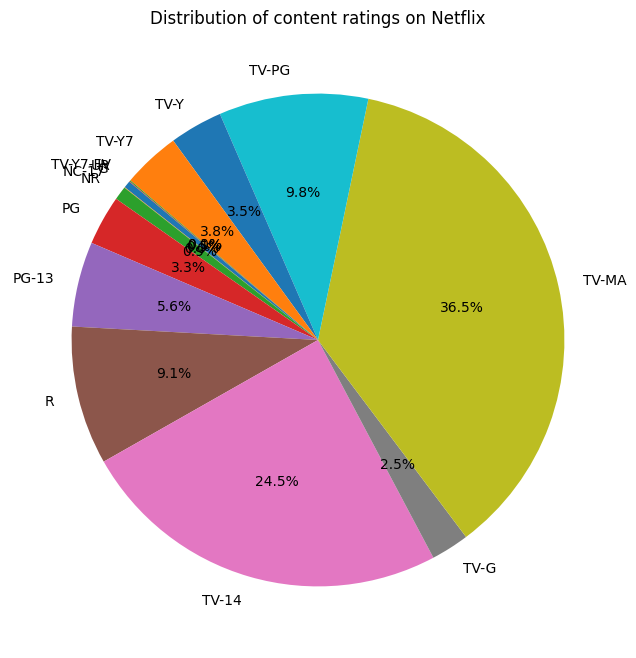

In [23]:
plt.figure(figsize=(8,8))

plt.pie(
    x['counts'], 
    labels=x['rating'], 
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Distribution of content ratings on Netflix')

plt.show()

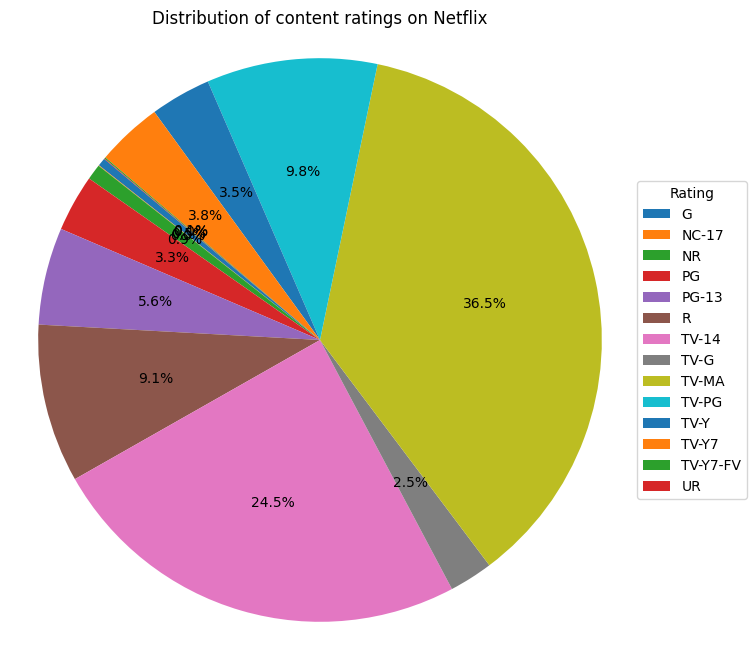

In [24]:
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    x['counts'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Distribution of content ratings on Netflix')

plt.legend(
    wedges,
    x['rating'],
    title="Rating",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.axis('equal')

plt.show()

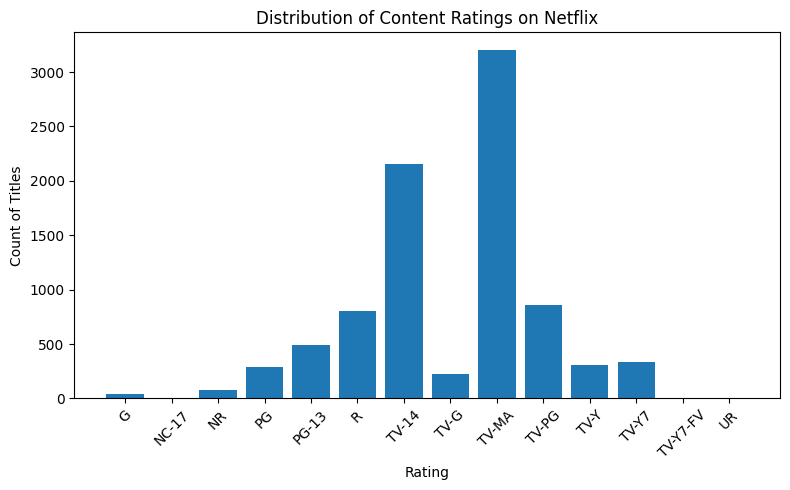

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    x['rating'], 
    x['counts']
)

plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count of Titles')

plt.xticks(rotation=45)   # rotating labels so they don't overlap

plt.tight_layout()
plt.show()

### Analyzing the top 5 directors on Netflix

In [26]:
director_list = pd.DataFrame
print(director_list)

<class 'pandas.core.frame.DataFrame'>


In [27]:
director_list = df['director'].str.split(',').explode().str.strip().reset_index(drop=True)
print(director_list)

0       Kirsten Johnson
1               Unknown
2       Julien Leclercq
3               Unknown
4               Unknown
             ...       
9590      David Fincher
9591            Unknown
9592    Ruben Fleischer
9593       Peter Hewitt
9594        Mozez Singh
Name: director, Length: 9595, dtype: object


In [28]:
director_list = director_list.to_frame()
print(director_list)

             director
0     Kirsten Johnson
1             Unknown
2     Julien Leclercq
3             Unknown
4             Unknown
...               ...
9590    David Fincher
9591          Unknown
9592  Ruben Fleischer
9593     Peter Hewitt
9594      Mozez Singh

[9595 rows x 1 columns]


In [29]:
director_list.columns = ['Director']    # renaming the column to 'Director' for clarity and better readability. 
print(director_list)

             Director
0     Kirsten Johnson
1             Unknown
2     Julien Leclercq
3             Unknown
4             Unknown
...               ...
9590    David Fincher
9591          Unknown
9592  Ruben Fleischer
9593     Peter Hewitt
9594      Mozez Singh

[9595 rows x 1 columns]


In [30]:
directors = director_list.groupby(["Director"]).size().reset_index(name='Total counts')
print(directors)

                 Director  Total counts
0             A. L. Vijay             2
1            A. Raajdheep             1
2               A. Salaam             1
3         A.R. Murugadoss             2
4         Aadish Keluskar             1
...                   ...           ...
4987           Éric Warin             1
4988     Ísold Uggadóttir             1
4989  Óskar Thór Axelsson             1
4990     Ömer Faruk Sorak             3
4991         Şenol Sönmez             2

[4992 rows x 2 columns]


In [31]:
directors = directors[directors.Director != 'Unknown']  # filtering out the 'Unknown' directors to focus on those with known names.
print(directors)

                 Director  Total counts
0             A. L. Vijay             2
1            A. Raajdheep             1
2               A. Salaam             1
3         A.R. Murugadoss             2
4         Aadish Keluskar             1
...                   ...           ...
4987           Éric Warin             1
4988     Ísold Uggadóttir             1
4989  Óskar Thór Axelsson             1
4990     Ömer Faruk Sorak             3
4991         Şenol Sönmez             2

[4991 rows x 2 columns]


In [32]:
  # sorting the directors by total counts in descending order and selecting the top 10 directors with the most titles on Netflix.
top_directors = directors.sort_values(by='Total counts', ascending=False)
print(top_directors)

           Director  Total counts
3747  Rajiv Chilaka            22
1905      Jan Suter            21
3798    Raúl Campos            19
4455    Suhas Kadav            16
2864   Marcus Raboy            16
...             ...           ...
9      Aaron Hancox             1
8       Aaron Burns             1
7        Aanand Rai             1
6        Aamir Khan             1
5      Aamir Bashir             1

[4991 rows x 2 columns]


In [33]:
 # Top5 directors with the most titles on Netflix
top5_directors = top_directors.head(5)
print(top5_directors)

           Director  Total counts
3747  Rajiv Chilaka            22
1905      Jan Suter            21
3798    Raúl Campos            19
4455    Suhas Kadav            16
2864   Marcus Raboy            16


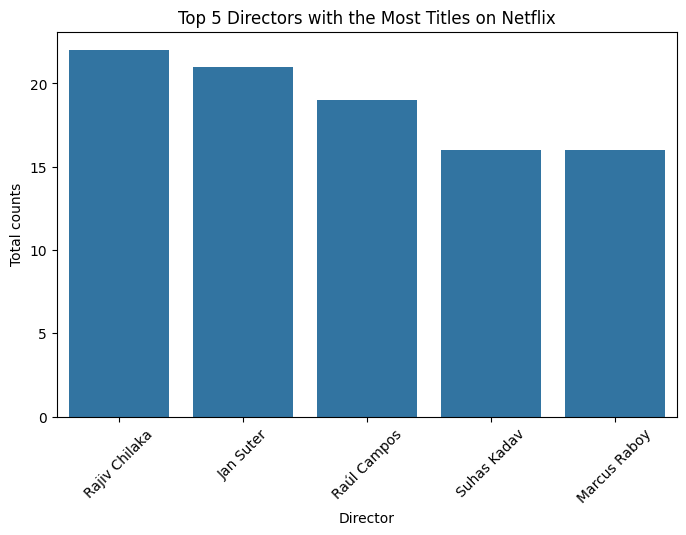

In [34]:
# Visualizing the top 5 directors with the most titles on Netflix using a bar plot.
plt.figure(figsize=(8,5))

sns.barplot(x='Director', y='Total counts', data=top5_directors)

plt.title('Top 5 Directors with the Most Titles on Netflix')
plt.xticks(rotation=45)

plt.show()

### Analyzing the top 5 actors of Netflix

C:\Users\premier\AppData\Local\Temp\ipykernel_4656\3107599188.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barChart2.set_xticklabels(barChart2.get_xticklabels(), rotation=45)


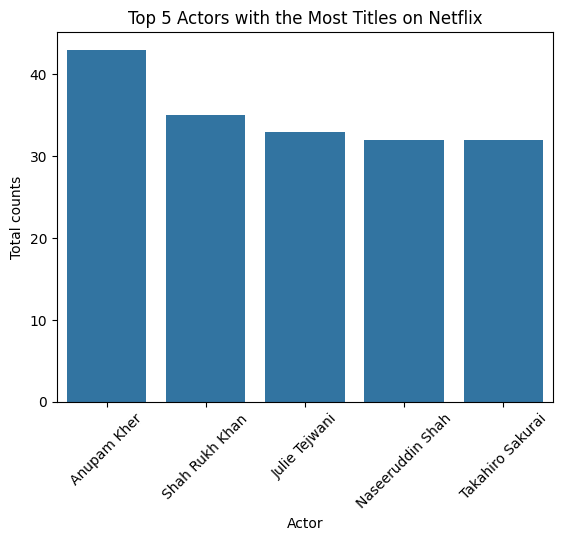

In [35]:
cast_df = df['cast'].str.split(',').explode().str.strip().reset_index(drop=True) 
cast_df = cast_df.to_frame()
cast_df.columns = ['Actor']  # renaming the column to 'Cast' for clarity and better readability.

actors = cast_df.groupby(["Actor"]).size().reset_index(name='Total counts')
actors = actors[actors.Actor != 'Unknown']  # filtering out the 'Unknown' actors to focus on those with known names.
actors = actors.sort_values(by='Total counts', ascending=False)
top5Actors = actors.head(5)
top5_directors = top5_directors.sort_values(by='Total counts', ascending=False)
barChart2 = sns.barplot(x='Actor', y='Total counts', data=top5Actors)
barChart2.set_title('Top 5 Actors with the Most Titles on Netflix')
barChart2.set_xticklabels(barChart2.get_xticklabels(), rotation=45)
plt.show()


### Analyzing the content produced on netflix based on years

In [36]:
df1 = df[['type','release_year']]
df1 = df1.rename(columns={ 'release_year': 'Release Year'})
df2 = df1.groupby(['Release Year', 'type']).size().reset_index(name='Total counts')
print(df2)

     Release Year     type  Total counts
0            1925  TV Show             1
1            1942    Movie             2
2            1943    Movie             3
3            1944    Movie             3
4            1945    Movie             3
..            ...      ...           ...
114          2019  TV Show           397
115          2020    Movie           517
116          2020  TV Show           436
117          2021    Movie           277
118          2021  TV Show           315

[119 rows x 3 columns]


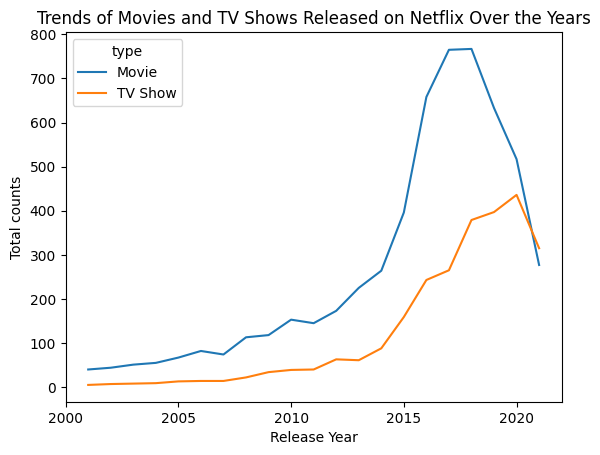

In [37]:
df2 = df2[df2['Release Year'] > 2000]  # filtering out thus years. Movies and TV shows released on Netflix from 2000 onwards,
graph = sns.lineplot(x='Release Year', y='Total counts', hue='type', data=df2)
graph.set_title('Trends of Movies and TV Shows Released on Netflix Over the Years')
graph.set_xticks(range(2000, 2025, 5))  # setting x-ticks to show every 5 years for better readability

### Analyzing top 5 countries in production of content on Netflix

C:\Users\premier\AppData\Local\Temp\ipykernel_4656\30388556.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barChart.set_xticklabels(barChart.get_xticklabels(), rotation=45)


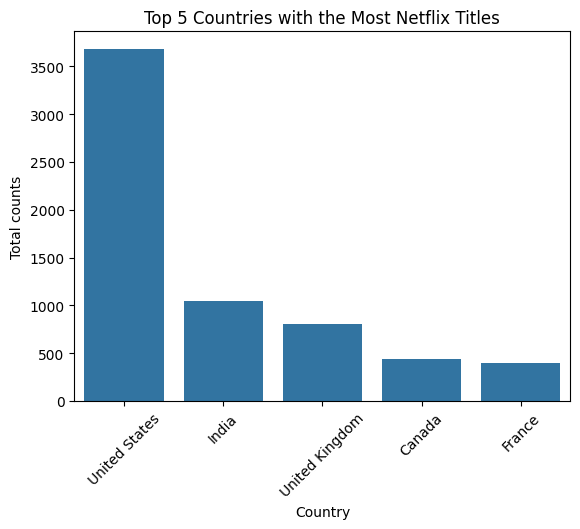

In [38]:
country_df = df['country'].str.split(',').explode().str.strip().reset_index(drop=True)
country_df = country_df.to_frame()
country_df.columns = ['Country']  # renaming column for clarity

countries = country_df.groupby(["Country"]).size().reset_index(name='Total counts')

countries = countries[countries.Country != 'Unknown']  # remove unknown values

countries = countries.sort_values(by='Total counts', ascending=False)

top5Countries = countries.head(5)

barChart = sns.barplot(x='Country', y='Total counts', data=top5Countries)

barChart.set_title('Top 5 Countries with the Most Netflix Titles')

barChart.set_xticklabels(barChart.get_xticklabels(), rotation=45)

plt.show()

## Sentiment Analysis of Netflix

In [45]:
from textblob import TextBlob 
df3 = df[['release_year', 'description']]
df3 = df3.rename(columns={'release_year': 'Release Year', 'description': 'Description'})
for index, row in df3.iterrows():
    d = row['Description']
    testimonial = Textblob(d)
    p = testimonial.sentiment.polarity
    if p==0:
        sent = 'Neutral'
    elif p>0:
        sent = 'Positive'
    else:
        sent = 'Negative'
    df3.loc[index, 'sentiment'] = sent

df3 = df3.groupby(['Release Year', 'sentiment']).size().reset_index(name='Total counts')
df3 = df3[df3['Release Year'] > 2005]
          
          
plt.figure()

sns.barplot(
    data=df3,
    x='Release Year',
    y='Total counts',
    hue='sentiment'
)

plt.title('Sentiment Analysis of Netflix Titles Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Total Count')

plt.show()

NameError: name 'Textblob' is not defined

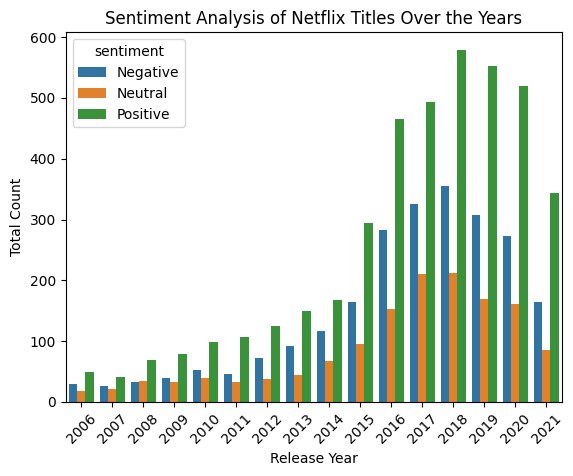

In [47]:
df3 = df[['release_year', 'description']]
df3 = df3.rename(columns={'release_year': 'Release Year', 'description': 'Description'})

for index, row in df3.iterrows():
    d = row['Description']
    testimonial = TextBlob(d)
    p = testimonial.sentiment.polarity
    
    if p == 0:
        sent = 'Neutral'
    elif p > 0:
        sent = 'Positive'
    else:
        sent = 'Negative'
    
    df3.loc[index, 'sentiment'] = sent

df3 = df3.groupby(['Release Year', 'sentiment']).size().reset_index(name='Total counts')
df3 = df3[df3['Release Year'] > 2005]

plt.figure()

sns.barplot(
    data=df3,
    x='Release Year',
    y='Total counts',
    hue='sentiment'
)

plt.title('Sentiment Analysis of Netflix Titles Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Total Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

plt.show()

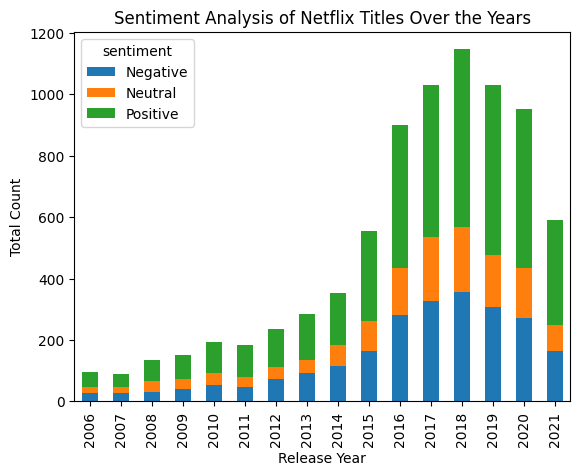

In [48]:
# Convert to pivot (this is the key step)
pivot_df = df3.pivot(index='Release Year', columns='sentiment', values='Total counts')

# Plot stacked bar chart
pivot_df.plot(kind='bar', stacked=True)

plt.title('Sentiment Analysis of Netflix Titles Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Total Count')

plt.show()